In [12]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

c0 ={'acc':'#941717', 'coriolis':'#388E3C','ggrad':'#42A5F5', 'wind':'#FFA000'}

surface_drifters = ['CARTHE', 'CODE', 'HEREON', 'MELODI', 'SPOTTER']
depth_drifters = ['OSMC','SVP', 'SVPOGS', 'SVPSIO']

____
# Colocalization definition
- select the nearest in time of a SWOT image drifter point 

_______
# Data

In [2]:
drifters_sources = 'all_med_variational_10min_v0.nc'
#DRIFTERS = {'all_med_variational_10min_v0' : os.path.join(zarr_dir, 'drifters_all_med_variational_10min_v0.csv')}
drifter_file = os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv'))
ALTI = {
    'swot250naive' : os.path.join(zarr_dir, 'swot_250_'+drifters_sources.replace('.nc', '')+'_naive.csv'), 
    'swot250gauss1e3' : os.path.join(zarr_dir, 'swot_250_'+drifters_sources.replace('.nc', '')+'_gauss1e3.csv'), 
}
WIND = {'era5' : os.path.join(zarr_dir, 'era5_'+drifters_sources.replace('.nc', '')+'.csv')}

In [3]:
def prepared_drifters() : 
    dfr = pd.read_csv(drifter_file).set_index('row_number')
    dfr['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfr.latitude * np.pi / 180)
    dfr['coriolise']= -dfr.f * dfr.velocity_north
    dfr['coriolisn']= dfr.f * dfr.velocity_east
    dfr = dfr.rename(columns = {'acceleration_north':'accn', 'acceleration_east':'acce'})
    return dfr[['datetime', 'longitude', 'latitude', 'pass_number','time_to_swot','cycle_number','drifter_id','drifter_type','accn', 'acce', 'coriolise', 'coriolisn']]

def prepared_alti(alti_key, ggrad_var=['duacs_ssha_karin_2_filtered','cvl_mean_dynamic_topography_cnes_cls_22','cvl_ocean_tide_fes_2022']) :
    dfs = pd.read_csv(ALTI[alti_key]).set_index('row_number')
    dfs = dfs[['ggrade_'+v for v in ggrad_var]+['ggradn_'+v for v in ggrad_var]]
    dfs['ggrade_eta'] = dfs.ggrade_duacs_ssha_karin_2_filtered + dfs.ggrade_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggrade_cvl_ocean_tide_fes_2022
    dfs['ggradn_eta'] = dfs.ggradn_duacs_ssha_karin_2_filtered + dfs.ggradn_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggradn_cvl_ocean_tide_fes_2022
    return dfs.rename(columns ={v : v+'_' +alti_key for v in dfs})
    
def prepared_wind(wind_key): 
    dfw = pd.read_csv(WIND[wind_key]).set_index('row_number')
    dfw = dfw[[v for v in dfw if ('winde' in v or 'windn' in v)]]
    return dfw.rename(columns ={v : v+'_' +wind_key for v in dfw})

In [4]:
df = pd.concat([prepared_drifters(), prepared_alti('swot250naive'), prepared_alti('swot250gauss1e3'), prepared_wind('era5')], axis=1)

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_64749/117234695.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfr = pd.read_csv(drifter_file).set_index('row_number')


In [5]:
df.columns

Index(['datetime', 'longitude', 'latitude', 'pass_number', 'time_to_swot',
       'cycle_number', 'drifter_id', 'drifter_type', 'accn', 'acce',
       'coriolise', 'coriolisn',
       'ggrade_duacs_ssha_karin_2_filtered_swot250naive',
       'ggrade_cvl_mean_dynamic_topography_cnes_cls_22_swot250naive',
       'ggrade_cvl_ocean_tide_fes_2022_swot250naive',
       'ggradn_duacs_ssha_karin_2_filtered_swot250naive',
       'ggradn_cvl_mean_dynamic_topography_cnes_cls_22_swot250naive',
       'ggradn_cvl_ocean_tide_fes_2022_swot250naive',
       'ggrade_eta_swot250naive', 'ggradn_eta_swot250naive',
       'ggrade_duacs_ssha_karin_2_filtered_swot250gauss1e3',
       'ggrade_cvl_mean_dynamic_topography_cnes_cls_22_swot250gauss1e3',
       'ggrade_cvl_ocean_tide_fes_2022_swot250gauss1e3',
       'ggradn_duacs_ssha_karin_2_filtered_swot250gauss1e3',
       'ggradn_cvl_mean_dynamic_topography_cnes_cls_22_swot250gauss1e3',
       'ggradn_cvl_ocean_tide_fes_2022_swot250gauss1e3',
       'ggrade_e

In [6]:
# select only nearest in time colocalisation
def select_nearest_swot_coloc(df):
    idx = df.groupby(['pass_number','cycle_number','drifter_id']).time_to_swot.idxmin()
    return df.loc[idx]

dfc = select_nearest_swot_coloc(df).dropna()
dfc

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,accn,acce,...,ggrade_cvl_ocean_tide_fes_2022_swot250gauss1e3,ggradn_duacs_ssha_karin_2_filtered_swot250gauss1e3,ggradn_cvl_mean_dynamic_topography_cnes_cls_22_swot250gauss1e3,ggradn_cvl_ocean_tide_fes_2022_swot250gauss1e3,ggrade_eta_swot250gauss1e3,ggradn_eta_swot250gauss1e3,winde0_era5,windn0_era5,winde15_era5,windn15_era5
row_number,,,,,,,,,,,,,,,,,,,,,
214,2023-04-01 23:40:00,5.632249,42.255307,3,0 days 00:02:32.696536,478,0-4351296,CARTHE,-2.339830e-05,-1.516511e-05,...,-5.831358e-07,-0.000003,-1.100597e-06,-4.378941e-07,-0.000017,-0.000005,-2.712372e-05,-2.016540e-05,-7.854672e-06,-3.114537e-06
1001,2023-04-01 23:40:00,5.558617,42.880708,3,0 days 00:02:32.696536,478,0-4388557,CARTHE,-3.028962e-06,5.276845e-06,...,-5.413172e-07,0.000001,2.512117e-05,-5.680131e-07,-0.000023,0.000026,-2.231952e-05,-1.806907e-05,-6.558906e-06,-2.919166e-06
500,2023-04-01 23:40:00,4.773443,42.198418,3,0 days 00:02:32.696536,478,0-4388599,CARTHE,2.738240e-06,-1.169734e-06,...,-4.738632e-07,0.000008,9.421445e-07,-4.473702e-07,0.000015,0.000008,-3.628125e-05,-1.837875e-05,-9.950441e-06,-2.090559e-06
858,2023-04-01 23:40:00,5.600033,41.562868,3,0 days 00:02:32.696536,478,2,MELODI,-1.010323e-05,-8.218213e-06,...,-5.831847e-07,0.000023,-2.018614e-06,-4.428720e-07,-0.000004,0.000020,-1.849554e-05,-1.165708e-05,-5.220599e-06,-1.618219e-06
357,2023-04-01 23:40:00,4.704619,41.945077,3,0 days 00:02:32.696536,478,300534060211000,SVP,8.290957e-07,-5.624849e-06,...,-4.780602e-07,-0.000009,-3.127146e-06,-4.614135e-07,-0.000010,-0.000012,-3.164639e-05,-1.316499e-05,-8.493855e-06,-1.131429e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383048,2023-07-09 19:00:00,2.122807,41.093707,16,0 days 00:03:38.131544384,577,295,HEREON,-9.669657e-06,-7.760517e-06,...,-7.277329e-07,0.000007,5.261937e-06,-7.280843e-07,0.000012,0.000011,1.495273e-07,7.314775e-07,8.343814e-08,1.669631e-07
382230,2023-07-09 22:40:00,1.552078,40.941677,16,0 days 03:43:38.131544384,577,4694223,CARTHE,2.564552e-06,5.472507e-06,...,-4.065954e-07,0.000008,2.828935e-06,-7.703162e-07,-0.000012,0.000010,4.363739e-07,1.306743e-06,1.899287e-07,2.873188e-07
382905,2023-07-09 19:00:00,1.794712,39.114167,16,0 days 00:03:38.131544384,577,6204608,OSMC,1.810231e-05,-9.967410e-07,...,4.123505e-07,-0.000022,-6.027253e-06,-1.372612e-06,0.000012,-0.000030,3.854295e-07,8.956766e-07,1.510286e-07,1.913502e-07


In [110]:
def find_combination(df):
    id_comb = []
    # Alti
    ggrade, ggradn = [v for v in df if 'ggrade' in v], [v for v in df if 'ggradn' in v]
    alti_var = [v.replace('ggrade_','') for v in ggrade]
    
    # Wind
    winde, windn = [v for v in df if 'winde' in v], [v for v in df if 'windn' in v]
    wind_var = [v.replace('winde','').replace('_', '') for v in winde]

    import itertools  

    couple = list(itertools.product(alti_var, wind_var))
    E, N = list(itertools.product(ggrade, winde)), list(itertools.product(ggradn, windn))
    
    id_comb = dict()
    for i in range(len(E)):
        le = {"acc" : "acce", "coriolis" : "coriolise", "ggrad":E[i][0], "wind":E[i][1]}
        ln = {"acc" : "accn", "coriolis" : "coriolisn", "ggrad":N[i][0], "wind":N[i][1]}
        id_comb['__'.join(couple[i])] = le, ln
    return id_comb

In [111]:
id_comb = find_combination(dfc)
id_comb

{'duacs_ssha_karin_2_filtered_swot250naive__0era5': ({'acc': 'acce',
   'coriolis': 'coriolise',
   'ggrad': 'ggrade_duacs_ssha_karin_2_filtered_swot250naive',
   'wind': 'winde0_era5'},
  {'acc': 'accn',
   'coriolis': 'coriolisn',
   'ggrad': 'ggradn_duacs_ssha_karin_2_filtered_swot250naive',
   'wind': 'windn0_era5'}),
 'duacs_ssha_karin_2_filtered_swot250naive__15era5': ({'acc': 'acce',
   'coriolis': 'coriolise',
   'ggrad': 'ggrade_duacs_ssha_karin_2_filtered_swot250naive',
   'wind': 'winde15_era5'},
  {'acc': 'accn',
   'coriolis': 'coriolisn',
   'ggrad': 'ggradn_duacs_ssha_karin_2_filtered_swot250naive',
   'wind': 'windn15_era5'}),
 'cvl_mean_dynamic_topography_cnes_cls_22_swot250naive__0era5': ({'acc': 'acce',
   'coriolis': 'coriolise',
   'ggrad': 'ggrade_cvl_mean_dynamic_topography_cnes_cls_22_swot250naive',
   'wind': 'winde0_era5'},
  {'acc': 'accn',
   'coriolis': 'coriolisn',
   'ggrad': 'ggradn_cvl_mean_dynamic_topography_cnes_cls_22_swot250naive',
   'wind': 'windn

In [113]:
def compute(df, id_comb):
    D = []
    for comb in id_comb :
        coords_list = ['datetime', 'longitude', 'latitude', 'pass_number','time_to_swot','cycle_number','drifter_id', 'drifter_type']
        ds = df[coords_list].to_xarray()
        import itertools
        ds['id_comb'] = comb
        
        for direction in ['e', 'n'] : 
            if direction == 'e' : l = id_comb[comb][0]
            if direction == 'n' : l = id_comb[comb][1]
                
            # sum 
            ds['sum'+direction] = sum([df[v] for v in l.values()])

            # simple var + sum- one term
            for v in list(l.keys()) : 
                ds[v+direction] = df[l[v]]
                ds['exc'+direction+'_'+v] = ds['sum'+direction]-ds[v+direction]
                
            #2 by 2 product    
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                ds['prod'+direction+'_'+'_'.join(c)] = ds[c[0]+direction] * ds[c[1]+direction]
                
        D.append(ds)
    DS = xr.concat(D, dim='id_comb').set_coords(coords_list)
    return DS
            

In [114]:
DS = compute(dfc, id_comb)
DSS = DS.where(DS.drifter_type.isin(surface_drifters), drop=True)
DSD = DS.where(DS.drifter_type.isin(depth_drifters), drop=True)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/core/dataset.py:4789: UserWarning: No index created for dimension id_comb because variable id_comb is not a coordinate. To create an index for id_comb, please first call `.set_coords('id_comb')` on this object.
  warnings.warn(


# Visualization

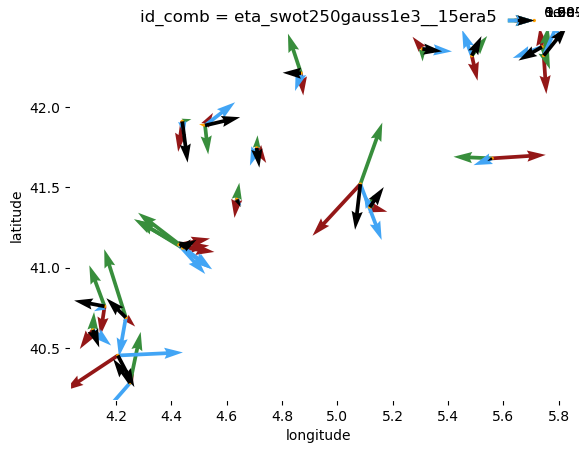

In [115]:
ds__= DS.sel(id_comb = 'eta_swot250gauss1e3__15era5').isel(row_number=slice(20,40))
fig, ax = plt.subplots()
s = 3e-4
ds__.plot.quiver('longitude', 'latitude', 'acce', 'accn', color =c0['acc'], pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'coriolise', 'coriolisn', color =c0['coriolis'],pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'ggrade', 'ggradn', color =c0['ggrad'],pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'winde', 'windn', color =c0['wind'],pivot='tail', scale=s)
ds__.plot.quiver('longitude', 'latitude', 'sume', 'sumn', color ='k', pivot='tail', scale=s )

In [116]:
def compute_mean_square(ds):
    dss = (ds**2).mean(dim='row_number')
    dss['Se'] = dss.acce + dss.coriolise + dss.ggrade + dss.winde
    dss['Sn'] = dss.accn + dss.coriolisn + dss.ggradn + dss.windn
    #true and err
    for direction in ['e', 'n']:
        for v in ['acc', 'coriolis', 'ggrad', 'wind'] : 
                dss['true'+direction+'_'+v] = (dss[v+direction] - dss['sum'+direction] + dss['exc'+direction+'_'+v])/2
                dss['err'+direction+'_'+v] = (dss[v+direction]  + dss['sum'+direction] - dss['exc'+direction+'_'+v])/2
    #pairs contributions
    for v in [v for v in dss if 'prod' in v]:
        dss[v]=-2*ds[v].mean(dim='row_number')
    return dss
dsm = compute_mean_square(DS)
dsms =compute_mean_square(DSS)
dsmd =compute_mean_square(DSD)

In [117]:
dsmd.sume/dsmd.Se, dsmd.sumn/dsmd.Sn

(<xarray.DataArray (id_comb: 16)> Size: 128B
 array([0.44077856, 0.41569219, 0.45112087, 0.4387633 , 0.46860975,
        0.46266945, 0.43066029, 0.40038996, 0.39850972, 0.37203057,
        0.44875443, 0.43668574, 0.46945914, 0.4641466 , 0.38376394,
        0.35160926])
 Coordinates:
   * id_comb  (id_comb) <U63 4kB 'duacs_ssha_karin_2_filtered_swot250naive__0e...,
 <xarray.DataArray (id_comb: 16)> Size: 128B
 array([0.43863392, 0.43576423, 0.41537173, 0.41392018, 0.49715514,
        0.49794269, 0.3915631 , 0.38761287, 0.40427807, 0.40206974,
        0.41391637, 0.41213656, 0.49533423, 0.49615591, 0.35612374,
        0.35257364])
 Coordinates:
   * id_comb  (id_comb) <U63 4kB 'duacs_ssha_karin_2_filtered_swot250naive__0e...)

In [118]:
dsmd.sume/dsmd.Se

<xarray.DataArray (id_comb: 16)> Size: 128B
array([0.44077856, 0.41569219, 0.45112087, 0.4387633 , 0.46860975,
       0.46266945, 0.43066029, 0.40038996, 0.39850972, 0.37203057,
       0.44875443, 0.43668574, 0.46945914, 0.4641466 , 0.38376394,
       0.35160926])
Coordinates:
  * id_comb  (id_comb) <U63 4kB 'duacs_ssha_karin_2_filtered_swot250naive__0e...

In [119]:
dsms.sume/dsms.Se

<xarray.DataArray (id_comb: 16)> Size: 128B
array([0.33933043, 0.38796932, 0.3270126 , 0.41834009, 0.32461307,
       0.41911853, 0.33150373, 0.37825229, 0.3065449 , 0.35824937,
       0.32736321, 0.4190049 , 0.32481797, 0.41930315, 0.297529  ,
       0.34743412])
Coordinates:
  * id_comb  (id_comb) <U63 4kB 'duacs_ssha_karin_2_filtered_swot250naive__0e...

In [120]:
# Best comb
bs =dsms.sel(id_comb = 'eta_swot250gauss1e3__0era5')
bd =dsmd.sel(id_comb = 'eta_swot250gauss1e3__15era5')

In [121]:
bs

<xarray.Dataset> Size: 636B
Dimensions:               ()
Coordinates:
    id_comb               <U63 252B 'eta_swot250gauss1e3__0era5'
Data variables: (12/48)
    sume                  float64 8B 2.598e-10
    acce                  float64 8B 1.911e-10
    exce_acc              float64 8B 3.467e-10
    coriolise             float64 8B 3.959e-10
    exce_coriolis         float64 8B 5.325e-10
    ggrade                float64 8B 2.557e-10
    ...                    ...
    truen_coriolis        float64 8B 3.03e-10
    errn_coriolis         float64 8B 8.712e-11
    truen_ggrad           float64 8B 1.51e-10
    errn_ggrad            float64 8B 1.397e-10
    truen_wind            float64 8B 1.262e-11
    errn_wind             float64 8B -7.415e-12

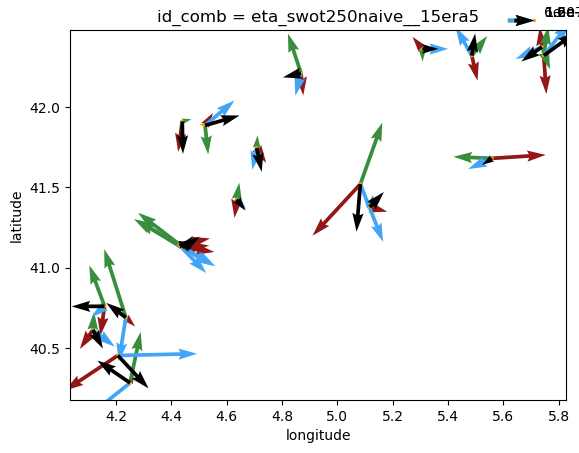

In [138]:
def synthetic_figure(ds, direction, ax, xlim=None) :
    plt.rcParams["axes.edgecolor"] = "w"
    a=1.5
    bbox = dict(facecolor='w', alpha=0.8, edgecolor='w')
    def prod(key1, key2) :
        return 'prod'+direction+'_'+key1+'_'+key2
        
    ts = float(ds['S'+direction])
    print(ts)
    #gap between bars for readability
    if xlim : b=xlim/400
    else : b=ts/400
    
    ## INDIVIDUAL MS ##
    ax.barh(2*a, ds['acc'+direction], color= c0['acc'], label = 'Inertial acceleration')
    ax.barh(2*a, ds['coriolis'+direction], left =ds['acc'+direction]+b , color= c0['coriolis'], label = 'Coriolis acceleration')
    ax.barh(2*a, ds['ggrad'+direction], left =ds['acc'+direction]+ds['coriolis'+direction]+2*b , color= c0['ggrad'], label = 'Pressure gradient term')
    ax.barh(2*a, ds['wind'+direction], left =ds['acc'+direction]+ds['coriolis'+direction]+ds['ggrad'+direction]+3*b, color= c0['wind'], label = 'Wind term')
    

    ax.text(ts/2, 2*a+0.5, r'Individual MS $A_i$', ha='center') 
    #percentage + MS
    key = ['acc', 'coriolis', 'ggrad', 'wind']
    for i in range(len(key)) :
        ax.text(sum([ds[v+direction] for v in key[:i]])+ds[key[i]+direction]/2+i*b, 2*a, f'{int(np.rint((ds[key[i]+direction]/ts).values*100))} %', ha='center',bbox=bbox )
        ax.text(sum([ds[v+direction] for v in key[:i]])+ds[key[i]+direction]/2+i*b, 2*a-0.55, f'{np.format_float_scientific(ds[key[i]+direction].values,precision = 1)}', ha='center')
    
    #accolade
    c = 1e-12
    id1 =0
    id2 = ts + 3*b
    bx = [id1, id1, id2, id2]
    by = [3.70, 3.75, 3.75, 3.70]
    ax.plot(bx, by, 'k-', lw=2)
    ax.text(ts, 3.8, r'$\Sigma$', fontsize=15, ha='center')
    
    ## CAPTURED PHYSICAL + ERRORS PARTS ##
    ax.barh(1*a, ds['true'+direction+'_acc'], color= c0['acc'])
    ax.barh(1*a, ds['err'+direction+'_acc'], left = ds['true'+direction+'_acc'], color= 'lightgrey', label='Errors')
    ax.barh(1*a, ds['true'+direction+'_coriolis'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+b, color= c0['coriolis'])
    ax.barh(1*a, ds['err'+direction+'_coriolis'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis'], color= 'lightgrey')
    ax.barh(1*a, ds['true'+direction+'_ggrad'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+b, color= c0['ggrad'])
    if ds['err'+direction+'_ggrad']>0 : 
        ax.barh(1*a, ds['err'+direction+'_ggrad'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad'], color= 'lightgrey')
        ax.barh(1*a, ds['true'+direction+'_wind'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad']+ds['err'+direction+'_ggrad']+b, color= c0['wind'])
        ax.barh(1*a, ds['err'+direction+'_wind'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad']+ds['err'+direction+'_ggrad']+ds['true'+direction+'_wind'], color= 'lightgrey')
    else : 
        print('ok')
        ax.barh(1*a, ds['true'+direction+'_wind'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad']+2*b, color= c0['wind'])
        ax.barh(1*a, ds['err'+direction+'_wind'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad']+ds['true'+direction+'_wind']+2*b, color= 'lightgrey')
    
    ax.text(ts/2, 1*a+0.5, r'Balanced physical and errors parts MS $B_i$ and $E_i$', ha='center') 
    #percentage + MS
    key = ['true'+direction+'_acc','err'+direction+'_acc', 'true'+direction+'_coriolis','err'+direction+'_coriolis', 'true'+direction+'_ggrad','err'+direction+'_ggrad', 'true'+direction+'_wind', 'err'+direction+'_wind']
    for i in range(len(key)) :
        d=0
        dx=0
        if i==len(key)-1 : 
            d=-0.1*a 
            dx = 3e-11
        if i==len(key)-2 : d=0.1*a 
        #if 'aviso' in dic['ggrad'] and i==len(key)-3 : d=-0.1*a
        ax.text(sum([ds[v] for v in key[:i]])+ds[key[i]]/2+i*b/2, a+d, f'{int(np.rint((ds[key[i]]/ts).values*100))} %', ha='center', bbox=bbox)
        d=0        
        if i%2 ==1 : d=-0.1*a
        ax.text(sum([ds[v] for v in key[:i]])+ds[key[i]]/2+i*b/2+dx, a+d -0.55, f'{np.format_float_scientific(ds[key[i]].values,precision = 1)}', ha='center')
        
    ## PAIRS + RESIDUAL ##
    plt.rcParams['hatch.linewidth'] = 10
    plt.rcParams['hatch.color'] = c0['ggrad']
    ax.barh(0, ds[prod('coriolis', 'ggrad')], color=c0['coriolis'], hatch='/')
    plt.rcParams['hatch.color'] = c0['coriolis']
    ax.barh(0, ds[prod('acc', 'coriolis')], color=c0['acc'], hatch='/', left = ds[prod('coriolis', 'ggrad')]+b)
    plt.rcParams['hatch.color'] = c0['acc']
    ax.barh(0, ds[prod('acc', 'ggrad')], color=c0['ggrad'], hatch='/', left = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+2*b)
    plt.rcParams['hatch.color'] = c0['wind']
    ax.barh(0, ds[prod('coriolis', 'wind')], color=c0['coriolis'], hatch='/', left = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+ds[prod('acc', 'ggrad')]+3*b)
    ax.barh(0, ds['sum'+direction], color='lightgrey', left = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+ds[prod('acc', 'ggrad')]+ds[prod('coriolis', 'wind')]+4*b)

    tts = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+ds[prod('acc', 'ggrad')]+ds[prod('coriolis', 'wind')]+4*b+ds['sum'+direction]
    print(tts)
    sum_pairs = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+ds[prod('acc', 'ggrad')]+ds[prod('coriolis', 'wind')]+3*b
    ax.text(sum_pairs/2, 0.6, r"Pairs' contributions $X_{ij}$", ha='center')
    
    #accolade
    c = 1e-12
    id1 =0
    id2 = sum_pairs
    bx = [id1, id1, id2, id2]
    by = [0.45, 0.5, 0.5, 0.45]
    ax.plot(bx, by, 'k-', lw=2)
    ax.text(sum_pairs + ds['sum'+direction]/2, 0.5, r'$S$', ha='center')

    #percentage + MS
    key = [prod('coriolis', 'ggrad'),prod('acc', 'coriolis'), prod('acc', 'ggrad'), prod('coriolis', 'wind')]
    for i in range(len(key)) :
        ax.text(sum([ds[v] for v in key[:i]])+ds[key[i]]/2+i*b, 0, f'{int(np.rint((ds[key[i]]/ts).values*100))} %', ha='center', bbox=bbox)
        d=0
        #if 'aviso' in dic['ggrad'] and key[i]== prod('acc', 'ggrad') : d = -0.1*a
        ax.text(sum([ds[v] for v in key[:i]])+ds[key[i]]/2+i*b, 0-0.55+d, f'{np.format_float_scientific(ds[key[i]].values,precision = 1)}', ha='center')
    
    ax.text(sum([ds[v] for v in key]) + ds["sum"+direction]/2+i*b, 0, f'{int(np.rint((ds["sum"+direction]/ts).values*100))} %', ha='center', bbox=bbox)
    ax.text(sum([ds[v] for v in key]) + ds["sum"+direction]/2+i*b, 0-0.55, f'{np.format_float_scientific(ds["sum"+direction].values,precision = 1)}', ha='center')

    # FIGURE SET
    ax.set_yticks([])
    if not xlim : xlim=tts
    ax.set_xlim(-1e-11, xlim+1e-11)
    ax.set_ylim(-1, 4.1)
    ax.get_yaxis().set_visible(False)
    ax.annotate('',xy=(xlim,-1),xytext=(0,-1),arrowprops={'arrowstyle':'->', 'facecolor':'k'})
    ax.set_xlabel(r'$[m^2.s^{-4}]$')
    

8.731588223329798e-10
<xarray.DataArray ()> Size: 8B
array(9.10898258e-10)
Coordinates:
    id_comb  <U63 252B 'eta_swot250gauss1e3__0era5'


Text(0.5, 0.98, 'Surface-drifters, ggrad gauss 1e3, ekman rio15')

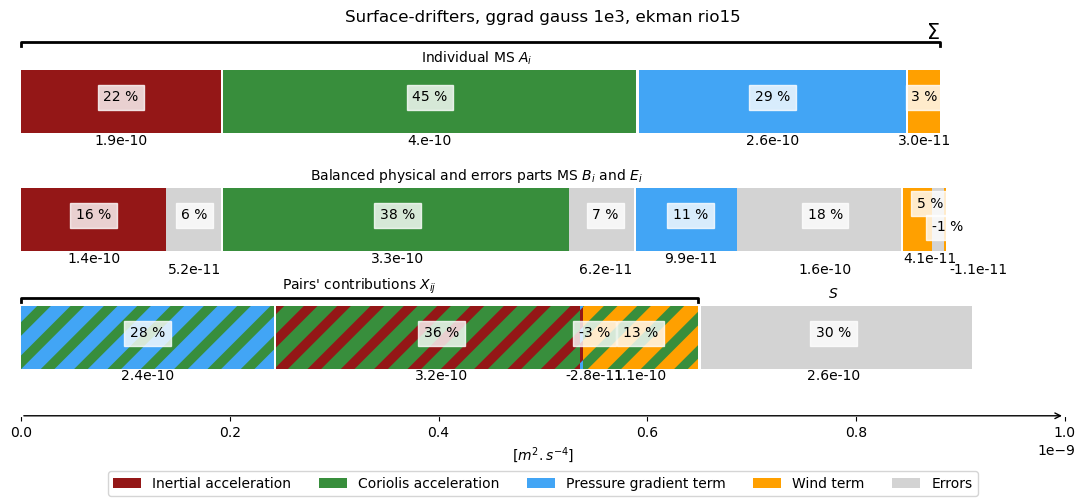

In [141]:
plt.rcParams["axes.edgecolor"] = "w"
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(11,5), frameon=False, )

synthetic_figure(bs,'e', ax, xlim=1e-9) 
fig.legend(ncol=5,loc='lower center')
fig.tight_layout(rect=[0,0.04,1,1])#left, bottom, right, top (default is 0,0,1,1)
fig.suptitle('Surface-drifters, ggrad gauss 1e3, ekman rio15')
#fig.savefig('images/synth_alg.png',bbox_inches='tight',   dpi=300)

5.509468292380456e-10
<xarray.DataArray ()> Size: 8B
array(5.6276738e-10)
Coordinates:
    id_comb  <U63 252B 'eta_swot250gauss1e3__15era5'


Text(0.5, 0.98, 'Depth-drifters, ggrad gauss 1e3, ekman rio15')

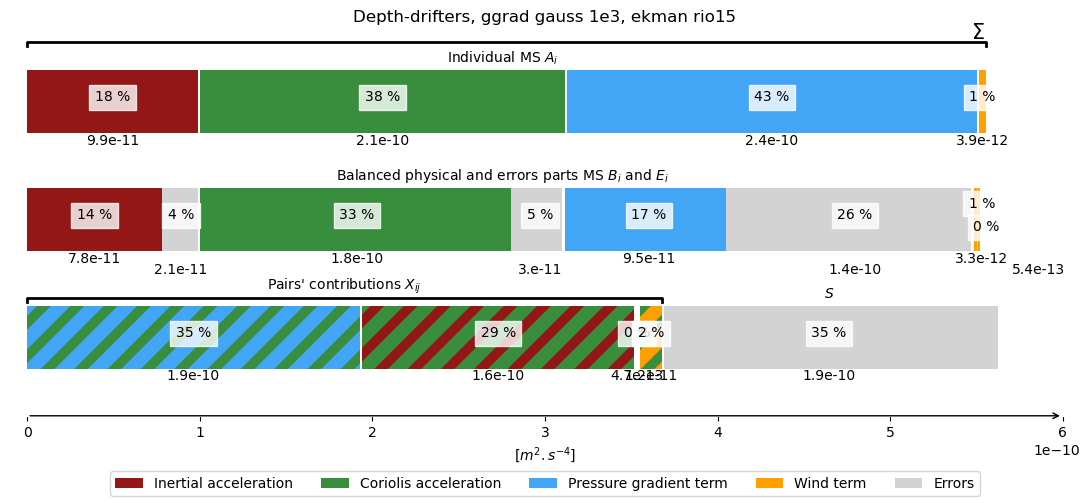

In [142]:
plt.rcParams["axes.edgecolor"] = "w"
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(11,5), frameon=False, )

synthetic_figure(bd,'e', ax, xlim=6e-10) 
fig.legend(ncol=5,loc='lower center')
fig.tight_layout(rect=[0,0.04,1,1])#left, bottom, right, top (default is 0,0,1,1)
fig.suptitle('Depth-drifters, ggrad gauss 1e3, ekman rio15')
#fig.savefig('images/synth_alg.png',bbox_inches='tight',   dpi=300)

In [143]:
# Best comb
bs =dsms.sel(id_comb = 'eta_swot250naive__0era5')
bd =dsmd.sel(id_comb = 'eta_swot250naive__15era5')

9.208955102969264e-10
<xarray.DataArray ()> Size: 8B
array(9.60648836e-10)
Coordinates:
    id_comb  <U63 252B 'eta_swot250naive__0era5'


Text(0.5, 0.98, 'Surface-drifters, ggrad gauss 1e3, ekman rio15')

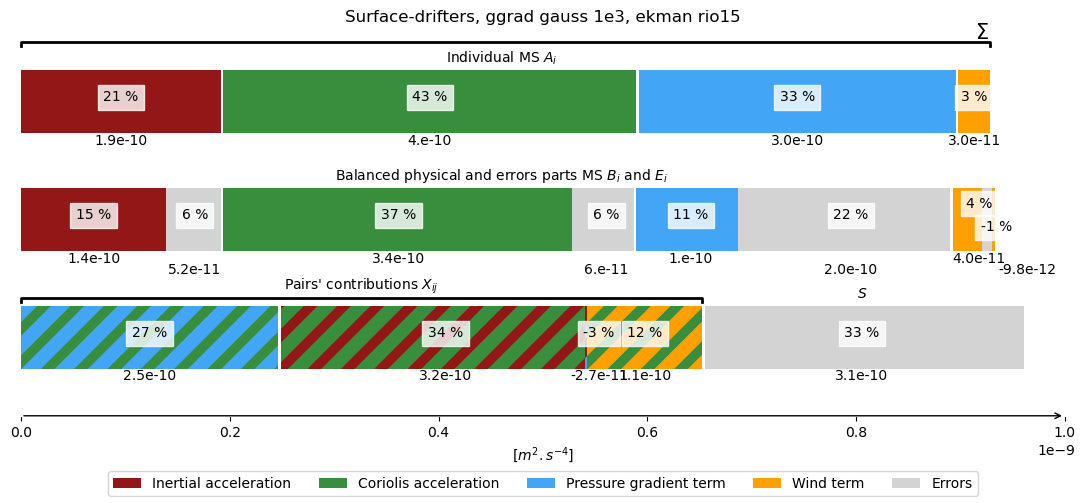

In [144]:
plt.rcParams["axes.edgecolor"] = "w"
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(11,5), frameon=False, )

synthetic_figure(bs,'e', ax, xlim=1e-9) 
fig.legend(ncol=5,loc='lower center')
fig.tight_layout(rect=[0,0.04,1,1])#left, bottom, right, top (default is 0,0,1,1)
fig.suptitle('Surface-drifters, ggrad gauss 1e3, ekman rio15')
#fig.savefig('images/synth_alg.png',bbox_inches='tight',   dpi=300)